This program plots the radial profile of the Tycho SNR in 2003 vs 2021

In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import numpy as np

In [2]:
Rprofile2003_file = 'BW2003_rprofile.fits'
Rprofile2021_file = 'BW2021_rprofile.fits'

In [3]:
with fits.open(Rprofile2003_file, ignore_missing_end=True) as hdu_list:
    hdu_list.verify('silentfix')
    hist_data2003 = hdu_list[1].data

with fits.open(Rprofile2021_file, ignore_missing_end=True) as hdu_list:
    hdu_list.verify('silentfix')
    hist_data2021 = hdu_list[1].data

# print(hist_data2003.columns)
# Grab radius data
radius2003 = hist_data2003['RMID']
radius2021 = hist_data2021['RMID']
# Need to convert from pixels to arcsec using plate scale of 0.492"
radius2003 = radius2003 * 0.492
radius2021 = radius2021 * 0.492

# Grab the flux values given in photons/cm**2/pixel**2/s
flux2003 = hist_data2003['SUR_FLUX']
flux2021 = hist_data2021['SUR_FLUX']
# Convert flux to arcsec
flux2003 = flux2003 * 4.1311388723641
flux2021 = flux2021 * 4.1311388723641

# Grab the flux error values given in pixels**-2
fluxerr2003 = hist_data2003['SUR_FLUX_ERR']
fluxerr2021 = hist_data2021['SUR_FLUX_ERR']
# Convert to arcsec**-2
fluxerr2003 = fluxerr2003 * 4.1311388723641
fluxerr2021 = fluxerr2021 * 4.1311388723641


In [20]:
# Optionally create an astropy Table to see the data
tab2003 = Table(
    [radius2003, flux2003, fluxerr2003],
    names=('Radius (arcsec)', 'Flux (photons/cm**2/arcsec**2/s)', 'Flux Error (photons/cm**2/arcsec**2/s)')
)
tab2021 = Table(
    [radius2021, flux2021, fluxerr2021],
    names=('Radius (arcsec)', 'Flux (photons/cm**2/arcsec**2/s)', 'Flux Error (photons/cm**2/arcsec**2/s)')
)
# print(tab2003)
# print(tab2021)

print(f"2003 BW: {radius2003[np.argmax(flux2003)]} \n2021 BW: {radius2021[np.argmax(flux2021)]}")

2003 BW: 198.98940000000002 
2021 BW: 201.82630644


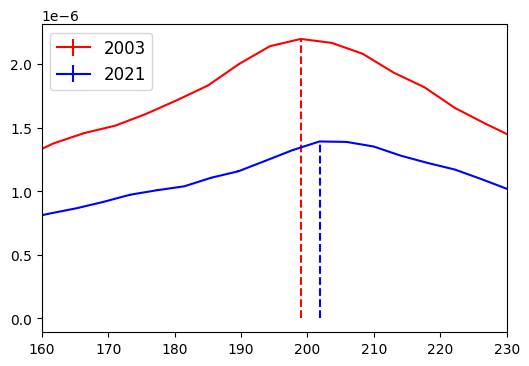

In [18]:
plt.figure(figsize=(6, 4))
plt.errorbar(radius2003, flux2003, yerr=fluxerr2003, fmt='r-',label='2003')
plt.errorbar(radius2021, flux2021, yerr=fluxerr2021, fmt='b-', label='2021')
plt.vlines(radius2003[np.argmax(flux2003)], 0, flux2003[np.argmax(flux2003)], linestyles='--', color='r')
plt.vlines(radius2021[np.argmax(flux2021)], 0, flux2021[np.argmax(flux2021)], linestyles='--', color='b')
plt.xlim(160, 230)
plt.legend(prop={'size': 12})
plt.show()